# 🧩 Notebook 2: Byte Pair Encoding (BPE)

**Based on Lecture 8 from Vizuara AI Series**

---

## 🎯 Learning Objectives

By the end of this notebook, you will:

1. Understand the **"Goldilocks" problem** in tokenization
2. Implement the **BPE algorithm** from scratch
3. Visualize the **iterative merging process**
4. Compare BPE with **tiktoken** (OpenAI's tokenizer)
5. Analyze **compression efficiency**

---

## 📚 Table of Contents

1. [The Goldilocks Problem](#1-the-goldilocks-problem)
2. [BPE Algorithm Overview](#2-bpe-algorithm-overview)
3. [Implementation: Step by Step](#3-implementation-step-by-step)
4. [Training the BPE Tokenizer](#4-training-the-bpe-tokenizer)
5. [Encoding and Decoding](#5-encoding-and-decoding)
6. [Comparison with tiktoken](#6-comparison-with-tiktoken)
7. [Compression Analysis](#7-compression-analysis)
8. [Key Takeaways](#8-key-takeaways)

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import torch
import pickle
import os

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


### Environment Setup (Colab/Local)

This cell detects whether you're running in Google Colab or locally and sets up the environment accordingly.

In [2]:
# ========================================
# ENVIRONMENT DETECTION & SETUP
# ========================================

# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except:
    IN_COLAB = False
    print("Running locally")

# Setup directories
if IN_COLAB:
    # Create necessary directories for Colab
    os.makedirs('data', exist_ok=True)
    os.makedirs('visualizations/tokenization', exist_ok=True)
    os.makedirs('visualizations/embeddings', exist_ok=True)
    os.makedirs('visualizations/data_pipeline', exist_ok=True)
    print("Created directories")
    
    # Set paths for Colab
    DATA_DIR = 'data'
    VIZ_DIR = 'visualizations'
else:
    # Use relative paths for local execution
    DATA_DIR = '../data'
    VIZ_DIR = '../visualizations'
    
    # Create directories if they don't exist (LOCAL FIX)
    os.makedirs(DATA_DIR, exist_ok=True)
    os.makedirs(f'{VIZ_DIR}/tokenization', exist_ok=True)
    os.makedirs(f'{VIZ_DIR}/embeddings', exist_ok=True)
    os.makedirs(f'{VIZ_DIR}/data_pipeline', exist_ok=True)
    print(f"Created directories: {DATA_DIR}, {VIZ_DIR}")

print(f"\nData directory: {DATA_DIR}")
print(f"Visualization directory: {VIZ_DIR}")

Running in Google Colab
Created directories

Data directory: data
Visualization directory: visualizations


---

## 1. The Goldilocks Problem

### 🐻 The Three Bears of Tokenization

In Notebook 1, we saw the trade-offs:

| Method | Vocab Size | Sequence Length | Problem |
|--------|-----------|----------------|----------|
| **Character** | ~65 | Very Long | ❌ Too many tokens |
| **Word** | ~100K+ | Short | ❌ Too many unknowns |
| **BPE** | ~50K | Moderate | ✅ Just right! |

### 🎯 What We Want

The ideal tokenizer should:

1. **Handle rare words**: No `<UNK>` tokens
2. **Efficient sequences**: Not too long
3. **Reasonable vocab**: Not too large
4. **Semantic units**: Meaningful sub-words

**BPE achieves all of this!**

### 💡 The Key Insight

Instead of choosing between characters and words, BPE learns **sub-word units** from the data:

```
"unhappiness" → ["un", "happi", "ness"]
"algorithm"   → ["algo", "rithm"]
"the"         → ["the"]  (common word stays whole)
```

---

## 2. BPE Algorithm Overview

### 📐 The Algorithm (High Level)

BPE is an **iterative compression algorithm**:

```
1. Start with individual bytes (256 tokens)
2. Count all adjacent pairs in the corpus
3. Find the most frequent pair
4. Merge that pair into a new token
5. Replace all occurrences in the text
6. Repeat until target vocabulary size
```

### 🔄 Example: Merging Process

```
Iteration 0: [t, h, e, m, o, d, e, s, t]
             Count pairs: ('t','h')=2, ('e','s')=1, ...
             Most frequent: ('t','h')

Iteration 1: [th, e, m, o, d, e, s, t]
             Create new token: 'th' = 256
             Count pairs: ('th','e')=2, ...
             Most frequent: ('th','e')

Iteration 2: [the, m, o, d, e, s, t]
             Create new token: 'the' = 257
             ...
```

### 🎯 Why This Works

- **Frequent patterns** (like "the", "ing") get merged early
- **Rare words** stay as character combinations
- **No unknown tokens** - can always fall back to bytes

---

## 2. Loading the Dataset

We'll use a sample of Shakespeare's text for this tutorial.

In [5]:
# ========================================
# DATA ACQUISITION
# ========================================

sample_path = f'{DATA_DIR}/sample.txt'

# Check if data already exists
if os.path.exists(sample_path):
    print(f"✅ Data file already exists: {sample_path}")
else:
    if IN_COLAB:
        # Download sample data automatically in Colab
        import urllib.request
        
        print("📥 Downloading sample data (Shakespeare text)...")
        url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
        
        try:
            urllib.request.urlretrieve(url, sample_path)
            print(f"✅ Downloaded successfully to {sample_path}")
        except Exception as e:
            print(f"❌ Error downloading file: {e}")
            print("\n💡 Alternative: You can manually upload a text file using:")
            print("   from google.colab import files")
            print("   uploaded = files.upload()")
    else:
        print(f"❌ Error: {sample_path} not found!")
        print(f"\n💡 Please create the file at: {sample_path}")
        print(f"   You can download it from:")
        print(f"   https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt")

# Verify and show stats
if os.path.exists(sample_path):
    with open(sample_path, 'r', encoding='utf-8') as f:
        text_preview = f.read()
    
    print(f"\n📊 File Statistics:")
    print(f"   Total characters: {len(text_preview):,}")
    print(f"   Total lines: {len(text_preview.splitlines()):,}")
    print(f"\n📝 First 200 characters:")
    print(f"   {text_preview[:200]}...")
    print(f"\n✅ Data ready for processing!")

✅ Data file already exists: data/sample.txt

📊 File Statistics:
   Total characters: 1,115,394
   Total lines: 40,000

📝 First 200 characters:
   First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you...

✅ Data ready for processing!


---

## 3. Implementation: Step by Step

### 📝 Load the Dataset

In [6]:
# Load dataset
with open(f'{DATA_DIR}/sample.txt', 'r', encoding='utf-8') as f:
    text = f.read()

print(f"📊 Dataset: {len(text):,} characters")
print(f"\n📝 Sample text:")
print(text[:200])

📊 Dataset: 1,115,394 characters

📝 Sample text:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


### 🔢 Convert to Bytes

BPE operates on **bytes**, not characters. This ensures it can handle any Unicode text.

In [7]:
# ┌─────────────────────────────────────────────────────────────────────┐
# │                    TEXT → BYTES CONVERSION                          │
# │                                                                     │
# │  Why bytes? BPE operates on bytes, not characters                   │
# │  This ensures it can handle ANY Unicode text                        │
# │                                                                     │
# │  Example:                                                           │
# │  "Hello" → UTF-8 encoding → [72, 101, 108, 108, 111]               │
# │  "世界"   → UTF-8 encoding → [228, 184, 150, 231, 149, 140]         │
# │                                                                     │
# │  Each byte is in range 0-255, giving us 256 base tokens            │
# │  BPE will learn to merge these bytes into larger units             │
# └─────────────────────────────────────────────────────────────────────┘

# Convert text to bytes
# .encode('utf-8') converts string to bytes, list() makes it a list of integers
tokens = list(text.encode('utf-8'))

### 🔍 Helper Function: Count Pairs

In [8]:
# ┌─────────────────────────────────────────────────────────────────────┐
# │                    PAIR COUNTING FUNCTION                           │
# │                                                                     │
# │  Given: ids = [1, 2, 3, 1, 2, 4, 1, 2]                             │
# │                                                                     │
# │  zip(ids, ids[1:]) creates adjacent pairs:                         │
# │    ids     = [1, 2, 3, 1, 2, 4, 1, 2]                              │
# │    ids[1:] = [2, 3, 1, 2, 4, 1, 2]                                 │
# │    pairs   = [(1,2), (2,3), (3,1), (1,2), (2,4), (4,1), (1,2)]    │
# │                                                                     │
# │  Result: {(1,2): 3, (2,3): 1, (3,1): 1, (2,4): 1, (4,1): 1}        │
# │                                                                     │
# │  This tells us (1,2) appears 3 times → best candidate for merge    │
# └─────────────────────────────────────────────────────────────────────┘

def get_stats(ids):
    """
    Count frequency of adjacent pairs in the sequence.
    
    Args:
        ids: List of token IDs
    
    Returns:
        Dictionary mapping pairs to their counts
    """
    counts = {}
    # zip(ids, ids[1:]) creates sliding window of size 2
    # e.g. [1,2,3] → [(1,2), (2,3)]
    for pair in zip(ids, ids[1:]):
        # Increment count for this pair (default to 0 if not seen before)
        counts[pair] = counts.get(pair, 0) + 1
    return counts

# Test the function
test_ids = [1, 2, 3, 1, 2, 4, 1, 2]
stats = get_stats(test_ids)

print("🧪 Testing get_stats():")
print(f"Input: {test_ids}")
print(f"Pair counts: {stats}")
print(f"\nMost frequent pair: {max(stats, key=stats.get)} (count: {max(stats.values())})")

🧪 Testing get_stats():
Input: [1, 2, 3, 1, 2, 4, 1, 2]
Pair counts: {(1, 2): 3, (2, 3): 1, (3, 1): 1, (2, 4): 1, (4, 1): 1}

Most frequent pair: (1, 2) (count: 3)


### 🔄 Helper Function: Merge Pairs

In [ ]:
# ┌─────────────────────────────────────────────────────────────────────┐
# │                    MERGE OPERATION LOGIC                            │
# │                                                                     │
# │  Input:  ids = [1, 2, 3, 1, 2, 4, 1, 2]                             │
# │          pair = (1, 2)                                              │
# │          idx = 99  (new token ID for merged pair)                   │
# │                                                                     │
# │  Process: Scan through ids, whenever we find (1,2) replace with 99  │
# │                                                                     │
# │  Step-by-step:                                                      │
# │  i=0: Found (1,2) → append 99, skip to i=2                          │
# │  i=2: Found 3 → append 3, i=3                                       │
# │  i=3: Found (1,2) → append 99, skip to i=5                          │
# │  i=5: Found 4 → append 4, i=6                                       │
# │  i=6: Found (1,2) → append 99, skip to i=8                          │
# │                                                                     │
# │  Output: [99, 3, 99, 4, 99]                                         │
# │                                                                     │
# │  Length: 8 → 5 (saved 3 tokens by merging 3 occurrences)            │
# └─────────────────────────────────────────────────────────────────────┘

def merge(ids, pair, idx):
    """
    Replace all occurrences of pair with new token idx.
    
    Args:
        ids: List of token IDs
        pair: Tuple of (token1, token2) to merge
        idx: New token ID for the merged pair
    
    Returns:
        New list with pairs replaced
    """
    newids = []
    i = 0
    while i < len(ids):
        # Check if current position and next position form the target pair
        if i < len(ids) - 1 and ids[i] == pair[0] and ids[i+1] == pair[1]:
            # Found the pair! Replace with new merged token
            newids.append(idx)
            i += 2  # Skip both tokens since we merged them
        else:
            # Not the pair we're looking for, keep the token as-is
            newids.append(ids[i])
            i += 1
    return newids

---

## 4. Training the BPE Tokenizer

### 🎓 Training Loop

Now we'll train the BPE tokenizer by iteratively merging the most frequent pairs.

In [ ]:
# Training parameters
vocab_size = 276  # 256 (bytes) + 20 (merges)
num_merges = vocab_size - 256

# Initialize
tokens_copy = list(tokens)  # Work on a copy
merges = {}  # Dictionary to store merge rules
vocab = {idx: bytes([idx]) for idx in range(256)}  # Initial vocab (all bytes)

# Track progress
vocab_sizes = [256]
iterations = [0]

print("🎓 Training BPE Tokenizer...")
print(f"Target vocabulary size: {vocab_size}")
print(f"Number of merges: {num_merges}")
print("\n" + "="*80)

# ┌─────────────────────────────────────────────────────────────────────┐
# │                    BPE TRAINING ALGORITHM                           │
# │                                                                     │
# │  Iterative compression: merge most frequent pairs repeatedly        │
# │                                                                     │
# │  Iteration 0: tokens = [t, h, e, _, t, h, e, ...]                   │
# │               pairs = {(t,h): 1000, (h,e): 800, ...}                │
# │               most frequent = (t,h)                                 │
# │               create new token 256 for 'th'                         │
# │               merge all (t,h) → 256                                 │
# │                                                                     │
# │  Iteration 1: tokens = [256, e, _, 256, e, ...]                     │
# │               pairs = {(256,e): 800, ...}                           │
# │               most frequent = (256,e)                               │
# │               create new token 257 for 'the'                        │
# │               merge all (256,e) → 257                               │
# │                                                                     │
# │  Continue until we reach target vocabulary size                     │
# │                                                                     │
# │  Result: vocab grows from 256 (bytes) to target size                │
# │          common patterns become single tokens                       │
# └─────────────────────────────────────────────────────────────────────┘

# Training loop
for i in range(num_merges):
    # Count pairs
    stats = get_stats(tokens_copy)
    
    # Find most frequent pair
    pair = max(stats, key=stats.get)
    
    # Create new token
    idx = 256 + i
    
    # Merge the pair
    tokens_copy = merge(tokens_copy, pair, idx)
    
    # Store the merge rule
    merges[pair] = idx
    
    # Update vocabulary
    vocab[idx] = vocab[pair[0]] + vocab[pair[1]]
    
    # Track progress
    vocab_sizes.append(256 + i + 1)
    iterations.append(i + 1)
    
    # Print progress
    if (i + 1) % 5 == 0 or i < 3:
        pair_bytes = vocab[pair[0]] + vocab[pair[1]]
        pair_str = pair_bytes.decode('utf-8', errors='replace')
        print(f"Merge {i+1:2d}: ({pair[0]:3d}, {pair[1]:3d}) → {idx:3d} | "
              f"'{pair_str}' | Count: {stats[pair]:4d} | Tokens: {len(tokens_copy):,}")

print("="*80)
print(f"\n✅ Training complete!")
print(f"Final vocabulary size: {len(vocab)}")
print(f"Original tokens: {len(tokens):,}")
print(f"Compressed tokens: {len(tokens_copy):,}")
print(f"Compression ratio: {len(tokens) / len(tokens_copy):.2f}x")

🎓 Training BPE Tokenizer...
Target vocabulary size: 276
Number of merges: 20

Merge  1: (101,  32) → 256 | 'e ' | Count: 27643 | Tokens: 1,087,751
Merge  2: (116, 104) → 257 | 'th' | Count: 22739 | Tokens: 1,065,012
Merge  3: (116,  32) → 258 | 't ' | Count: 16508 | Tokens: 1,048,504
Merge  5: (100,  32) → 260 | 'd ' | Count: 14165 | Tokens: 1,018,975
Merge 10: (121,  32) → 265 | 'y ' | Count: 10283 | Tokens: 959,487
Merge 15: (101, 110) → 270 | 'en' | Count: 7568 | Tokens: 916,368
Merge 20: (108, 108) → 275 | 'll' | Count: 6357 | Tokens: 882,737

✅ Training complete!
Final vocabulary size: 276
Original tokens: 1,115,394
Compressed tokens: 882,737
Compression ratio: 1.26x


### 📊 Visualize Vocabulary Growth

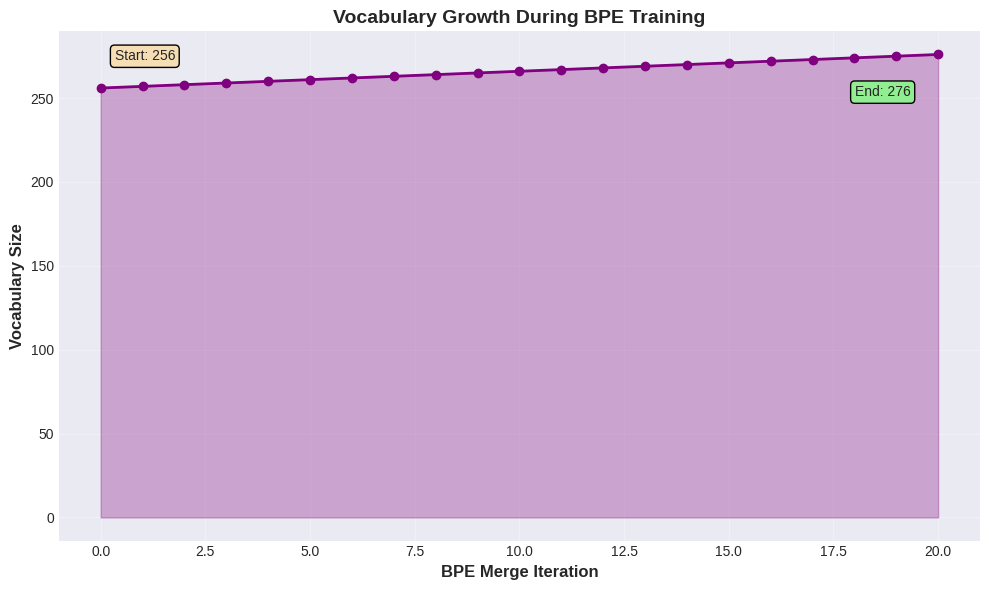


💡 Observation: Vocabulary grows linearly with each merge!


In [ ]:
# Plot vocabulary growth
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(iterations, vocab_sizes, marker='o', linewidth=2, 
       markersize=6, color='purple')
ax.fill_between(iterations, vocab_sizes, alpha=0.3, color='purple')

ax.set_xlabel('BPE Merge Iteration', fontsize=12, fontweight='bold')eiihccljjujflijtgtvtujbguktcivgjgrfjigrtrecg

ax.set_ylabel('Vocabulary Size', fontsize=12, fontweight='bold')
ax.set_title('Vocabulary Growth During BPE Training', 
            fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Add annotations
ax.annotate(f'Start: {vocab_sizes[0]}', 
           xy=(iterations[0], vocab_sizes[0]),
           xytext=(10, 20), textcoords='offset points',
           fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat'))

ax.annotate(f'End: {vocab_sizes[-1]}', 
           xy=(iterations[-1], vocab_sizes[-1]),
           xytext=(-60, -30), textcoords='offset points',
           fontsize=10, bbox=dict(boxstyle='round', facecolor='lightgreen'))

plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/tokenization/bpe_vocab_growth.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 Observation: Vocabulary grows linearly with each merge!")

### 🔍 Inspect Learned Merges

In [12]:
# Display first 10 merges
print("🔍 First 10 Learned Merges:")
print("="*80)

for i, (pair, idx) in enumerate(list(merges.items())[:10]):
    merged_bytes = vocab[idx]
    merged_str = merged_bytes.decode('utf-8', errors='replace')
    token1_str = vocab[pair[0]].decode('utf-8', errors='replace')
    token2_str = vocab[pair[1]].decode('utf-8', errors='replace')
    
    print(f"{i+1:2d}. '{token1_str}' + '{token2_str}' → '{merged_str}' (ID: {idx})")

print("\n💡 Notice: Common patterns like spaces + letters get merged first!")

🔍 First 10 Learned Merges:
 1. 'e' + ' ' → 'e ' (ID: 256)
 2. 't' + 'h' → 'th' (ID: 257)
 3. 't' + ' ' → 't ' (ID: 258)
 4. 's' + ' ' → 's ' (ID: 259)
 5. 'd' + ' ' → 'd ' (ID: 260)
 6. ',' + ' ' → ', ' (ID: 261)
 7. 'o' + 'u' → 'ou' (ID: 262)
 8. 'e' + 'r' → 'er' (ID: 263)
 9. 'i' + 'n' → 'in' (ID: 264)
10. 'y' + ' ' → 'y ' (ID: 265)

💡 Notice: Common patterns like spaces + letters get merged first!


---

## 5. Encoding and Decoding

### 🔢 Encode Function

In [13]:
# ┌─────────────────────────────────────────────────────────────────────┐
# │                    BPE ENCODING PIPELINE                            │
# │                                                                     │
# │  Step 1: Convert text to bytes                                      │
# │  "Hello" → [72, 101, 108, 108, 111]                                │
# │                                                                     │
# │  Step 2: Apply learned merges iteratively                           │
# │  Start with byte-level tokens, then merge based on training         │
# │                                                                     │
# │  Example with merges: {(72,101): 256, (256,108): 257}              │
# │  [72, 101, 108, 108, 111]                                           │
# │    ↓ merge (72,101)→256                                             │
# │  [256, 108, 108, 111]                                               │
# │    ↓ merge (256,108)→257                                            │
# │  [257, 108, 111]                                                    │
# │    ↓ no more applicable merges                                      │
# │  Final: [257, 108, 111]                                             │
# │                                                                     │
# │  Key: We apply merges in the order they were learned (lowest idx)  │
# └─────────────────────────────────────────────────────────────────────┘

def encode_bpe(text):
    """
    Encode text using trained BPE tokenizer.
    
    Args:
        text: String to encode
    
    Returns:
        List of token IDs
    """
    # Start with bytes - convert text to UTF-8 byte representation
    # This ensures we can handle any Unicode text
    tokens = list(text.encode('utf-8'))
    
    # Apply merges iteratively until no more merges are possible
    while len(tokens) >= 2:
        # Get pair statistics for current token sequence
        stats = get_stats(tokens)
        
        # Find the pair with lowest merge index (earliest learned merge)
        # merges.get(p, float('inf')) returns merge index or infinity if not in merges
        # min() selects the pair that was learned earliest in training
        pair = min(stats, key=lambda p: merges.get(p, float('inf')))
        
        # If pair not in merges, we're done - no more applicable merges
        if pair not in merges:
            break
        
        # Apply the merge: replace all occurrences of pair with merged token
        idx = merges[pair]
        tokens = merge(tokens, pair, idx)
    
    return tokens

### 🔤 Decode Function

In [14]:
# ┌─────────────────────────────────────────────────────────────────────┐
# │                    BPE DECODING PIPELINE                            │
# │                                                                     │
# │  Reverse the encoding process: token IDs → bytes → text            │
# │                                                                     │
# │  Example:                                                           │
# │  tokens = [257, 108, 111]                                           │
# │                                                                     │
# │  vocab[257] = b'Hel'  (learned merge)                              │
# │  vocab[108] = b'l'    (original byte)                              │
# │  vocab[111] = b'o'    (original byte)                              │
# │                                                                     │
# │  Step 1: Look up each token in vocab                               │
# │  [257, 108, 111] → [b'Hel', b'l', b'o']                            │
# │                                                                     │
# │  Step 2: Concatenate bytes                                          │
# │  b'Hel' + b'l' + b'o' = b'Hello'                                   │
# │                                                                     │
# │  Step 3: Decode bytes to UTF-8 string                              │
# │  b'Hello' → "Hello"                                                 │
# └─────────────────────────────────────────────────────────────────────┘

def decode_bpe(tokens):
    """
    Decode token IDs back to text.
    
    Args:
        tokens: List of token IDs
    
    Returns:
        Decoded string
    """
    # Look up each token ID in vocab to get its byte representation
    # vocab maps token IDs to their corresponding byte sequences
    text_bytes = b"".join(vocab[idx] for idx in tokens)
    
    # Decode bytes to UTF-8 string
    # errors='replace' handles any invalid UTF-8 sequences gracefully
    text = text_bytes.decode('utf-8', errors='replace')
    
    return text

### 🧪 Comprehensive Testing

In [15]:
# Test with various strings
test_strings = [
    "The cat sat on the mat.",
    "To be, or not to be?",
    "unhappiness",
    "algorithm"
]

print("🧪 BPE Encoding Tests:")
print("="*80)

for test_str in test_strings:
    encoded = encode_bpe(test_str)
    decoded = decode_bpe(encoded)
    match = "✅" if decoded == test_str else "❌"
    
    print(f"\nOriginal: '{test_str}'")
    print(f"Tokens:   {encoded}")
    print(f"Length:   {len(encoded)} tokens (vs {len(test_str)} chars)")
    print(f"Decoded:  '{decoded}'")
    print(f"Match:    {match}")

print("\n" + "="*80)

🧪 BPE Encoding Tests:

Original: 'The cat sat on the mat.'
Tokens:   [84, 104, 256, 99, 97, 258, 115, 97, 258, 274, 273, 256, 109, 97, 116, 46]
Length:   16 tokens (vs 23 chars)
Decoded:  'The cat sat on the mat.'
Match:    ✅

Original: 'To be, or not to be?'
Tokens:   [84, 269, 98, 101, 261, 268, 32, 110, 111, 258, 116, 269, 98, 101, 63]
Length:   15 tokens (vs 20 chars)
Decoded:  'To be, or not to be?'
Match:    ✅

Original: 'unhappiness'
Tokens:   [117, 110, 104, 97, 112, 112, 264, 101, 115, 115]
Length:   10 tokens (vs 11 chars)
Decoded:  'unhappiness'
Match:    ✅

Original: 'algorithm'
Tokens:   [97, 108, 103, 268, 105, 257, 109]
Length:   7 tokens (vs 9 chars)
Decoded:  'algorithm'
Match:    ✅



---

## 6. Comparison with tiktoken

### 📦 OpenAI's tiktoken

Let's compare our BPE implementation with OpenAI's production tokenizer.

In [16]:
# Try to import tiktoken
try:
    import tiktoken
    
    # Load GPT-2 tokenizer
    enc = tiktoken.get_encoding("gpt2")
    
    print("✅ tiktoken loaded successfully!")
    print(f"GPT-2 vocabulary size: {enc.n_vocab:,}")
    
    # Compare tokenization
    test_text = "The quick brown fox jumps over the lazy dog."
    
    # Our BPE
    our_tokens = encode_bpe(test_text)
    
    # tiktoken
    tiktoken_tokens = enc.encode(test_text)
    
    print(f"\n📊 Comparison for: '{test_text}'")
    print("="*80)
    print(f"Our BPE:    {len(our_tokens)} tokens")
    print(f"tiktoken:   {len(tiktoken_tokens)} tokens")
    print(f"Characters: {len(test_text)} chars")
    print(f"\nOur tokens:     {our_tokens}")
    print(f"tiktoken tokens: {tiktoken_tokens}")
    
    print("\n💡 Note: tiktoken is more efficient because it was trained on much more data!")
    
except ImportError:
    print("⚠️ tiktoken not installed. Install with: pip install tiktoken")
    print("Skipping comparison...")

✅ tiktoken loaded successfully!
GPT-2 vocabulary size: 50,257

📊 Comparison for: 'The quick brown fox jumps over the lazy dog.'
Our BPE:    37 tokens
tiktoken:   10 tokens
Characters: 44 chars

Our tokens:     [84, 104, 256, 113, 117, 105, 99, 107, 32, 98, 114, 111, 119, 110, 32, 102, 111, 120, 32, 106, 117, 109, 112, 259, 111, 118, 263, 273, 256, 108, 97, 122, 265, 100, 111, 103, 46]
tiktoken tokens: [464, 2068, 7586, 21831, 18045, 625, 262, 16931, 3290, 13]

💡 Note: tiktoken is more efficient because it was trained on much more data!


---

## 7. Compression Analysis

### 📊 Compression Efficiency

In [17]:
# Analyze compression on full dataset
full_encoded = encode_bpe(text)

# Character-level (from Notebook 1)
char_tokens = list(text)

# Statistics
print("📊 Compression Analysis:")
print("="*80)
print(f"Original text:     {len(text):,} characters")
print(f"Character tokens:  {len(char_tokens):,} tokens")
print(f"BPE tokens:        {len(full_encoded):,} tokens")
print(f"\nCompression ratio: {len(char_tokens) / len(full_encoded):.2f}x")
print(f"Tokens saved:      {len(char_tokens) - len(full_encoded):,}")
print(f"Reduction:         {(1 - len(full_encoded)/len(char_tokens))*100:.1f}%")

📊 Compression Analysis:
Original text:     1,115,394 characters
Character tokens:  1,115,394 tokens
BPE tokens:        882,737 tokens

Compression ratio: 1.26x
Tokens saved:      232,657
Reduction:         20.9%


### 📈 Visualize Compression

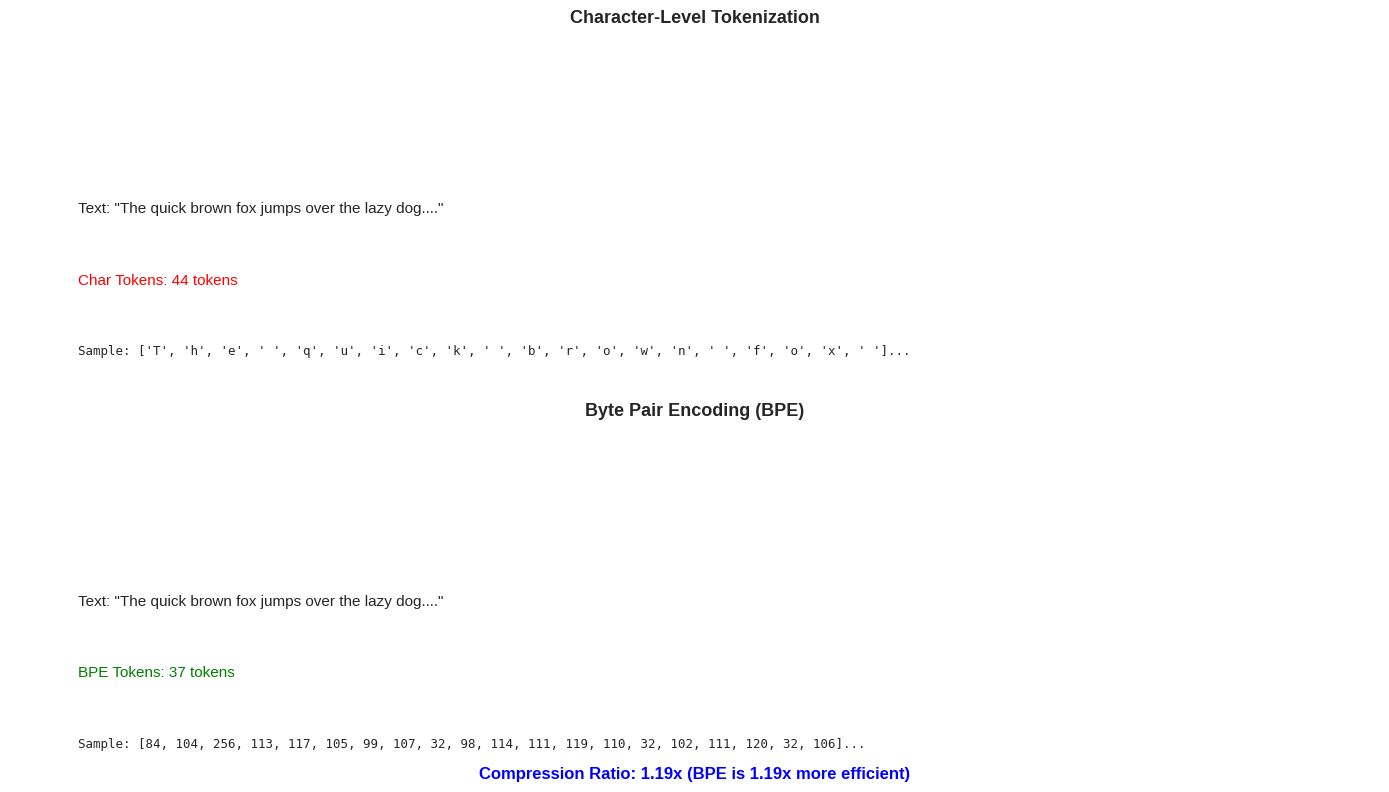


💡 BPE reduces sequence length by 15.9%!


In [18]:
# Create comparison visualization
sample_text = "The quick brown fox jumps over the lazy dog."
char_tokens_sample = list(sample_text)
bpe_tokens_sample = encode_bpe(sample_text)

# Visualize comparison
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Character-level
axes[0].text(0.05, 0.5, f'Text: "{sample_text[:50]}..."', 
            transform=axes[0].transAxes, fontsize=11, va='center')
axes[0].text(0.05, 0.3, f'Char Tokens: {len(char_tokens_sample)} tokens', 
            transform=axes[0].transAxes, fontsize=11, va='center', color='red')
axes[0].text(0.05, 0.1, f'Sample: {char_tokens_sample[:20]}...', 
            transform=axes[0].transAxes, fontsize=9, va='center', family='monospace')
axes[0].set_title('Character-Level Tokenization', fontsize=13, fontweight='bold')
axes[0].axis('off')

# BPE
axes[1].text(0.05, 0.5, f'Text: "{sample_text[:50]}..."', 
            transform=axes[1].transAxes, fontsize=11, va='center')
axes[1].text(0.05, 0.3, f'BPE Tokens: {len(bpe_tokens_sample)} tokens', 
            transform=axes[1].transAxes, fontsize=11, va='center', color='green')
axes[1].text(0.05, 0.1, f'Sample: {bpe_tokens_sample[:20]}...', 
            transform=axes[1].transAxes, fontsize=9, va='center', family='monospace')
axes[1].set_title('Byte Pair Encoding (BPE)', fontsize=13, fontweight='bold')
axes[1].axis('off')

# Comparison stats
compression_ratio = len(char_tokens_sample) / len(bpe_tokens_sample)
fig.text(0.5, 0.02, f'Compression Ratio: {compression_ratio:.2f}x (BPE is {compression_ratio:.2f}x more efficient)', 
         ha='center', fontsize=12, fontweight='bold', color='blue')

plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/tokenization/bpe_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💡 BPE reduces sequence length by {(1 - len(bpe_tokens_sample)/len(char_tokens_sample))*100:.1f}%!")

### 🎯 Token Length Distribution

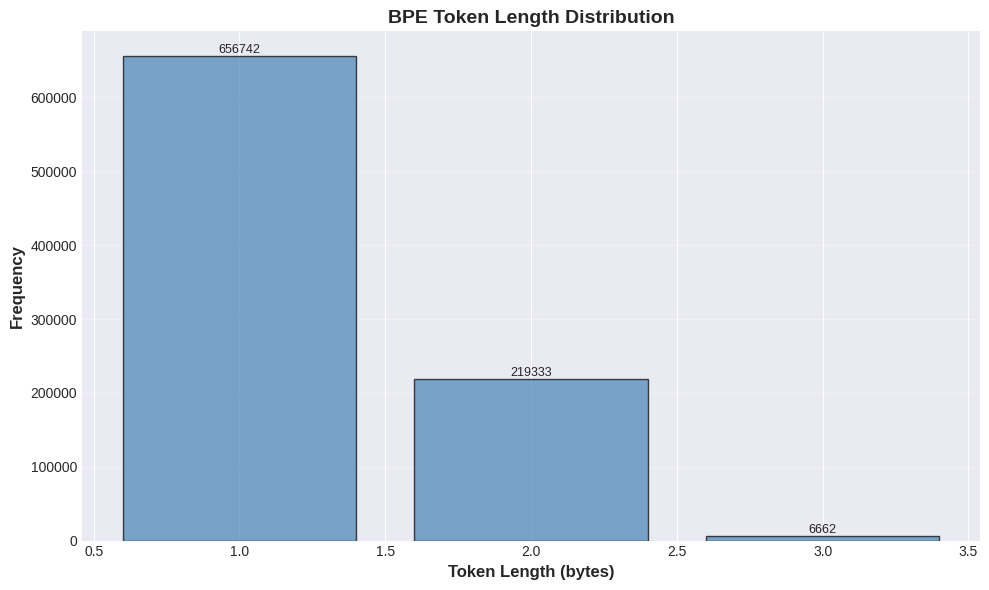


📊 Token Length Statistics:
Min length: 1 byte(s)
Max length: 3 bytes
Average:    1.26 bytes
Median:     1.0 bytes


In [19]:
# Analyze token lengths
token_lengths = [len(vocab[idx]) for idx in full_encoded]
length_counts = Counter(token_lengths)

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))

lengths = sorted(length_counts.keys())
counts = [length_counts[l] for l in lengths]

bars = ax.bar(lengths, counts, color='steelblue', alpha=0.7, edgecolor='black')
ax.set_xlabel('Token Length (bytes)', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title('BPE Token Length Distribution', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{count}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/tokenization/token_length_dist.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n📊 Token Length Statistics:")
print(f"Min length: {min(token_lengths)} byte(s)")
print(f"Max length: {max(token_lengths)} bytes")
print(f"Average:    {np.mean(token_lengths):.2f} bytes")
print(f"Median:     {np.median(token_lengths):.1f} bytes")

---

## 8. Key Takeaways

### ✅ What We Learned

1. **BPE solves the Goldilocks problem**:
   - Not too many tokens (like character-level)
   - Not too many unknowns (like word-level)
   - Just right! (~50K vocab, moderate sequences)

2. **The BPE algorithm**:
   - Starts with bytes (256 tokens)
   - Iteratively merges most frequent pairs
   - Learns sub-word units from data
   - No unknown tokens (can always fall back to bytes)

3. **Key functions**:
   - `get_stats()`: Count adjacent pairs
   - `merge()`: Replace pairs with new tokens
   - `encode_bpe()`: Text → Token IDs
   - `decode_bpe()`: Token IDs → Text

4. **Compression efficiency**:
   - Reduces sequence length significantly
   - Common patterns become single tokens
   - Rare words split into meaningful sub-words

5. **Why GPT uses BPE**:
   - Efficient: Shorter sequences = faster training
   - Flexible: Handles any text (no unknowns)
   - Semantic: Sub-words carry meaning
   - Scalable: Works for massive datasets

### 🎯 Next Steps

In **Notebook 3**, we'll build the **data pipeline**:
- Sliding window mechanism
- Input-target pair generation
- Batch construction
- PyTorch DataLoader

### 💾 Save the BPE Tokenizer

In [20]:
# Save BPE tokenizer
import pickle

bpe_tokenizer = {
    'merges': merges,
    'vocab': vocab,
    'vocab_size': len(vocab)
}

with open(f'{DATA_DIR}/bpe_tokenizer.pkl', 'wb') as f:
    pickle.dump(bpe_tokenizer, f)

print("✅ BPE tokenizer saved to f'{DATA_DIR}/bpe_tokenizer.pkl'")
print(f"\n📊 Tokenizer Summary:")
print(f"Vocabulary size: {len(vocab)}")
print(f"Number of merges: {len(merges)}")
print(f"Compression ratio: {len(tokens) / len(full_encoded):.2f}x")

✅ BPE tokenizer saved to f'{DATA_DIR}/bpe_tokenizer.pkl'

📊 Tokenizer Summary:
Vocabulary size: 276
Number of merges: 20
Compression ratio: 1.26x


---

## 📚 References

1. **Vizuara AI Lecture 8**: [The GPT Tokenizer (BPE)](https://www.youtube.com/watch?v=fKd8s29e-l4)

2. **Original BPE Paper**: [Neural Machine Translation of Rare Words with Subword Units](https://arxiv.org/abs/1508.07909) (Sennrich et al., 2016)

3. **GPT-2 Tokenizer**: [Language Models are Unsupervised Multitask Learners](https://d4mucfpksywv.cloudfront.net/better-language-models/language_models_are_unsupervised_multitask_learners.pdf)

4. **tiktoken**: [OpenAI's BPE Tokenizer](https://github.com/openai/tiktoken)

---

<div style="text-align: center; padding: 20px; background-color: #f0f0f0; border-radius: 10px;">
    <h2>🎉 Congratulations!</h2>
    <p>You've implemented Byte Pair Encoding from scratch!</p>
    <p><strong>Next:</strong> Notebook 3 - Data Pipeline & Batching</p>
</div>